## Neutrino cooling effects


This notebook reproduces the thermal-neutrino-cooling diagnostic plot. We compare a self-heating burn with and without thermal neutrino losses, then plot the nuclear energy generation rate, the thermal neutrino loss rate, and the resulting temperature evolution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pynucastro as pyna

from pynucastro.neutrino_cooling import sneut5

Start with a simple He-burning network:

In [2]:
net = pyna.network_helper(["p", "he4", "c12", "n13", "o16", "ne20"])

rho = 1.e5
T = 2.e8
tmax = 1.e10

comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("he4")] = 1.0
comp.normalize()

Y0 = comp.get_molar_array()

Now integrate the same self-heating network twice: once without thermal neutrino cooling, and once with thermal neutrino cooling included in the temperature evolution equation.

In [3]:
sol_no_cooling = net.integrate_network(
    tmax,
    rho,
    T,
    Y0,
    self_heating=True,
    rtol=1.e-8,
    atol=1.e-8,
)

sol_cooling = net.integrate_network(
    tmax,
    rho,
    T,
    Y0,
    self_heating=True,
    thermal_neutrinos=True,
    rtol=1.e-8,
    atol=1.e-8,
)

/Users/khanakbhargava/Desktop/Research/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/Users/khanakbhargava/Desktop/Research/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/Users/khanakbhargava/Desktop/Research/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/Users/khanakbhargava/Desktop/Research/pynucastro/pynucastro/rates/derived_rate.py:125: UserWarning: N13 partition fun

Compute the nuclear energy generation rate and the thermal neutrino loss rates:

In [4]:
mask_cooling = sol_cooling.t > 0.0
t_cooling = sol_cooling.t[mask_cooling]

eps_nuc = np.array([
    sol_cooling.energy_release_at(t)
    for t in t_cooling
])

eps_nu = []
for t in t_cooling:
    comp_t = pyna.Composition(sol_cooling.unique_nuclei)
    comp_t.set_molar_array(sol_cooling.Y_at(t))

    eps_nu.append(
        sneut5(sol_cooling.rho, sol_cooling.T_at(t), comp_t)
    )

eps_nu = np.array(eps_nu)

Finally, plot:

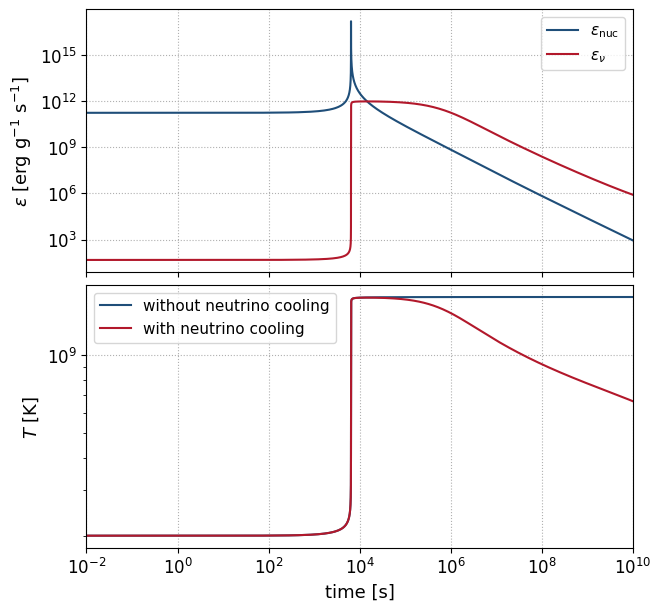

In [5]:
FS_LABEL = 13
FS_TICK = 12
FS_LEGEND = 11

c_nuc = "#1f4e79"
c_nu = "#b2182b"

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(6.5, 6.0),
    sharex=True,
    constrained_layout=True,
)

ax1.loglog(t_cooling, eps_nuc, color=c_nuc, label=r"$\epsilon_\mathrm{nuc}$")
ax1.loglog(t_cooling, eps_nu, color=c_nu, label=r"$\epsilon_\nu$")
ax1.set_ylabel(r"$\epsilon$ [erg g$^{-1}$ s$^{-1}$]", fontsize=FS_LABEL)
ax1.legend(fontsize=FS_LEGEND)
ax1.grid(ls=":")

mask_no_cooling = sol_no_cooling.t > 0.0

ax2.loglog(
    sol_no_cooling.t[mask_no_cooling],
    sol_no_cooling.Temp[mask_no_cooling],
    color=c_nuc,
    label="without neutrino cooling",
)
ax2.loglog(
    sol_cooling.t[mask_cooling],
    sol_cooling.Temp[mask_cooling],
    color=c_nu,
    label="with neutrino cooling",
)

ax2.set_xlabel("time [s]", fontsize=FS_LABEL)
ax2.set_ylabel(r"$T$ [K]", fontsize=FS_LABEL)
ax2.legend(fontsize=FS_LEGEND)
ax2.grid(ls=":")

for ax in (ax1, ax2):
    ax.tick_params(axis="both", labelsize=FS_TICK)

ax1.set_xlim(1.e-2, 1.e10)
ax2.set_xlim(1.e-2, 1.e10)

plt.show()